In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
df = pd.read_csv('../data/processed/analysis_ready.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13535 entries, 0 to 13534
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_type      13535 non-null  object 
 1   price              12547 non-null  float64
 2   area               13535 non-null  float64
 3   n_bedrooms         10648 non-null  float64
 4   n_bathrooms        9957 non-null   float64
 5   n_floors           7921 non-null   float64
 6   city_province      13535 non-null  object 
 7   district           13535 non-null  object 
 8   legal_docs         12197 non-null  object 
 9   facing_direction   5778 non-null   object 
 10  front_width        8018 non-null   float64
 11  front_road_width   3987 non-null   float64
 12  balcony_direction  3408 non-null   object 
 13  interior           6560 non-null   object 
dtypes: float64(7), object(7)
memory usage: 1.4+ MB


In [3]:
df.describe(include='all')

,property_type,price,area,n_bedrooms,n_bathrooms,n_floors,city_province,district,legal_docs,facing_direction,front_width,front_road_width,balcony_direction,interior
count,13535,12547.000000,13535.000000,10648.000000,9957.000000,7921.000000,13535,13535,12197,5778,8018.000000,3987.000000,3408,6560
unique,7,NaN,NaN,NaN,NaN,NaN,53,234,5,8,NaN,NaN,8,4
top,Nhà mặt tiền,NaN,NaN,NaN,NaN,NaN,TP.HCM,Thủ Đức,Sổ đỏ/hồng riêng,đông nam,NaN,NaN,đông nam,đầy đủ
freq,3513,NaN,NaN,NaN,NaN,NaN,4581,945,10281,1402,NaN,NaN,1043,3451
mean,NaN,17.820065,130.327140,3.862509,3.559506,3.971216,NaN,NaN,NaN,NaN,7.262085,15.444482,NaN,NaN
std,NaN,63.815539,461.486104,5.300731,4.995820,14.662936,NaN,NaN,NaN,NaN,12.819562,14.981973,NaN,NaN
min,NaN,0.002900,1.050000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,NaN,3.500000,54.000000,2.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,4.200000,6.000000,NaN,NaN
50%,NaN,7.350000,79.000000,3.000000,2.000000,3.000000,NaN,NaN,NaN,NaN,5.000000,12.000000,NaN,NaN
75%,NaN,16.000000,120.000000,4.000000,4.000000,5.000000,NaN,NaN,NaN,NaN,7.500000,20.000000,NaN,NaN


$\Rightarrow$ Existence of extreme outliers in numerical columns that needs to be removed for better visualizations

## **Outlier detection**
- physically impossible values (e.g., $\text{area} \le 0$, $\text{n\_bedrooms} < 1$ for a house).
- deal with outliers/noise records

In [4]:
outlier_rows = pd.DataFrame()
cols = ['price','area','n_bedrooms','n_bathrooms','front_width']

for c in cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[c] < lower) | (df[c] > upper)]
    outlier_rows = pd.concat([outlier_rows, outliers])


outlier_rows = outlier_rows.drop_duplicates()

# --- LOẠI OUTLIER RA KHỎI df GỐC ---
df.drop(outlier_rows.index,inplace=True)

In [5]:
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10948 entries, 0 to 10947
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_type      10948 non-null  object 
 1   price              10096 non-null  float64
 2   area               10948 non-null  float64
 3   n_bedrooms         8909 non-null   float64
 4   n_bathrooms        8373 non-null   float64
 5   n_floors           5963 non-null   float64
 6   city_province      10948 non-null  object 
 7   district           10948 non-null  object 
 8   legal_docs         9858 non-null   object 
 9   facing_direction   4818 non-null   object 
 10  front_width        5990 non-null   float64
 11  front_road_width   2891 non-null   float64
 12  balcony_direction  2864 non-null   object 
 13  interior           5433 non-null   object 
dtypes: float64(7), object(7)
memory usage: 1.2+ MB


In [72]:
df.describe()

,price,area,n_bedrooms,n_bathrooms,n_floors,front_width,front_road_width
count,10096.000000,10948.000000,8909.000000,8373.000000,5963.000000,5990.000000,2891.000000
mean,8.256927,77.899796,2.931418,2.709662,3.466376,5.228593,13.967416
std,7.492392,40.623859,1.352420,1.462511,4.717444,1.657969,15.462753
min,0.002900,1.050000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,50.000000,2.000000,2.000000,2.000000,4.000000,6.000000
50%,5.950000,70.000000,3.000000,2.000000,3.000000,5.000000,10.500000
75%,10.850000,97.625000,4.000000,4.000000,4.000000,6.000000,17.000000
max,160.000000,1151.000000,9.000000,7.000000,108.000000,21.000000,418.000000


## **Univariate**

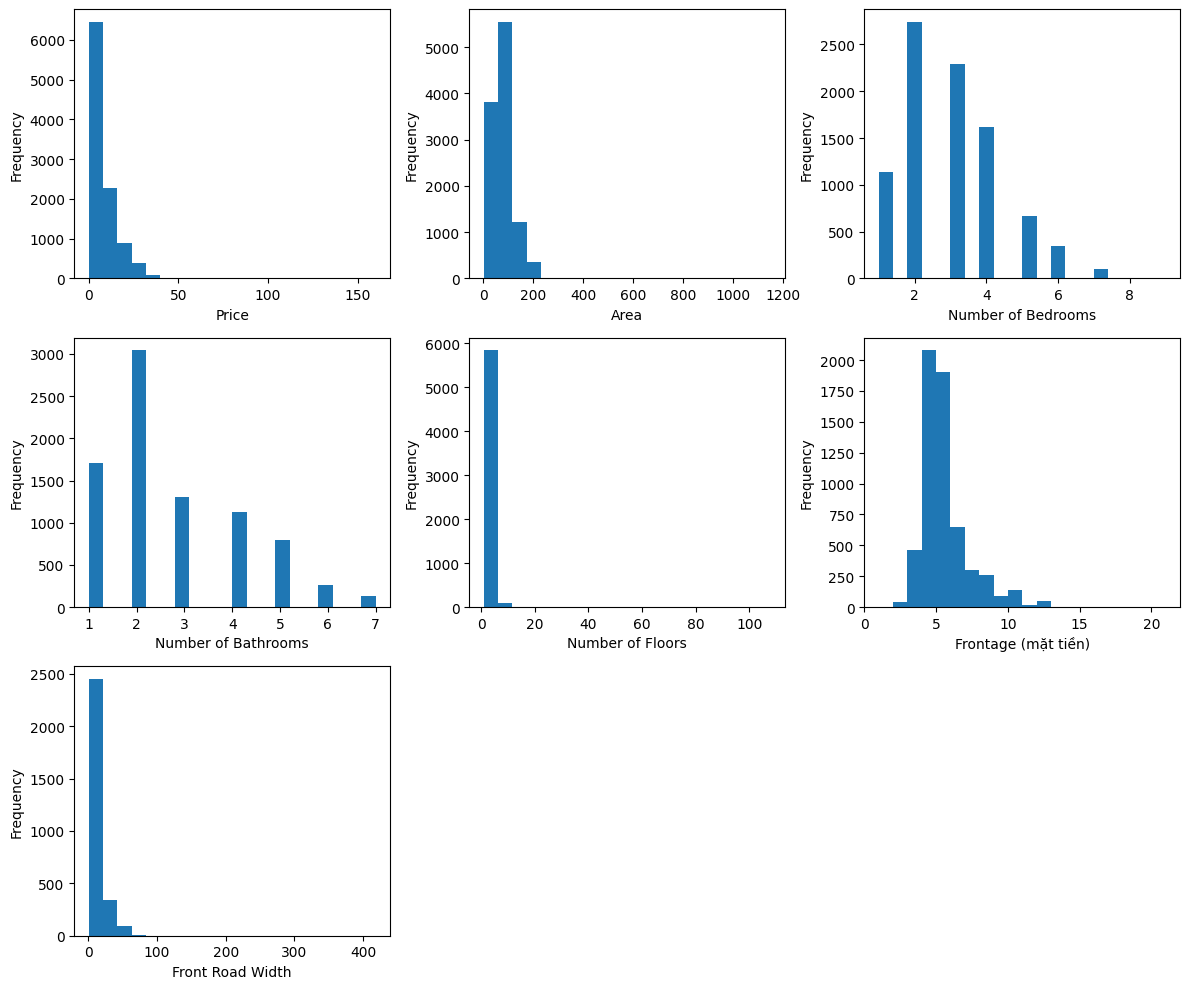

In [17]:
numeric_cols = ['price', 'area', 'n_bedrooms', 'n_bathrooms', 'n_floors', 'front_width', 'front_road_width'] 
descs = ['Price', 'Area', 'Number of Bedrooms', 'Number of Bathrooms', 'Number of Floors', 'Frontage (mặt tiền)', 'Front Road Width']
fig, axs = plt.subplots(3,3,figsize=(12,10))
axs = axs.flatten()
for i in range(len(numeric_cols)):
    axs[i].hist(df[numeric_cols[i]], bins=20)
    axs[i].set_ylabel('Frequency')
    axs[i].set_xlabel(f'{descs[i]}')
    # axs[i].set_title(f'Frequency of {descs[i]}')
for i in range(7,9):
    axs[i].set_visible(False)
plt.tight_layout()
plt.show()


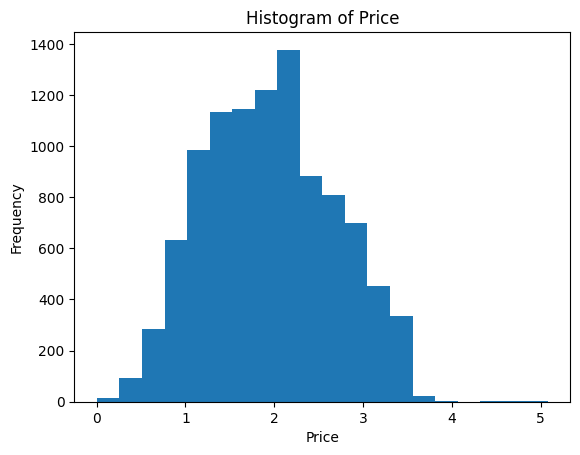

In [74]:
plt.hist(np.log1p(df.price), bins=20)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Price')
plt.show()

Phân phối giá thành có hình dáng gần phân phối lognormal (lấy log thì theo pp chuẩn)

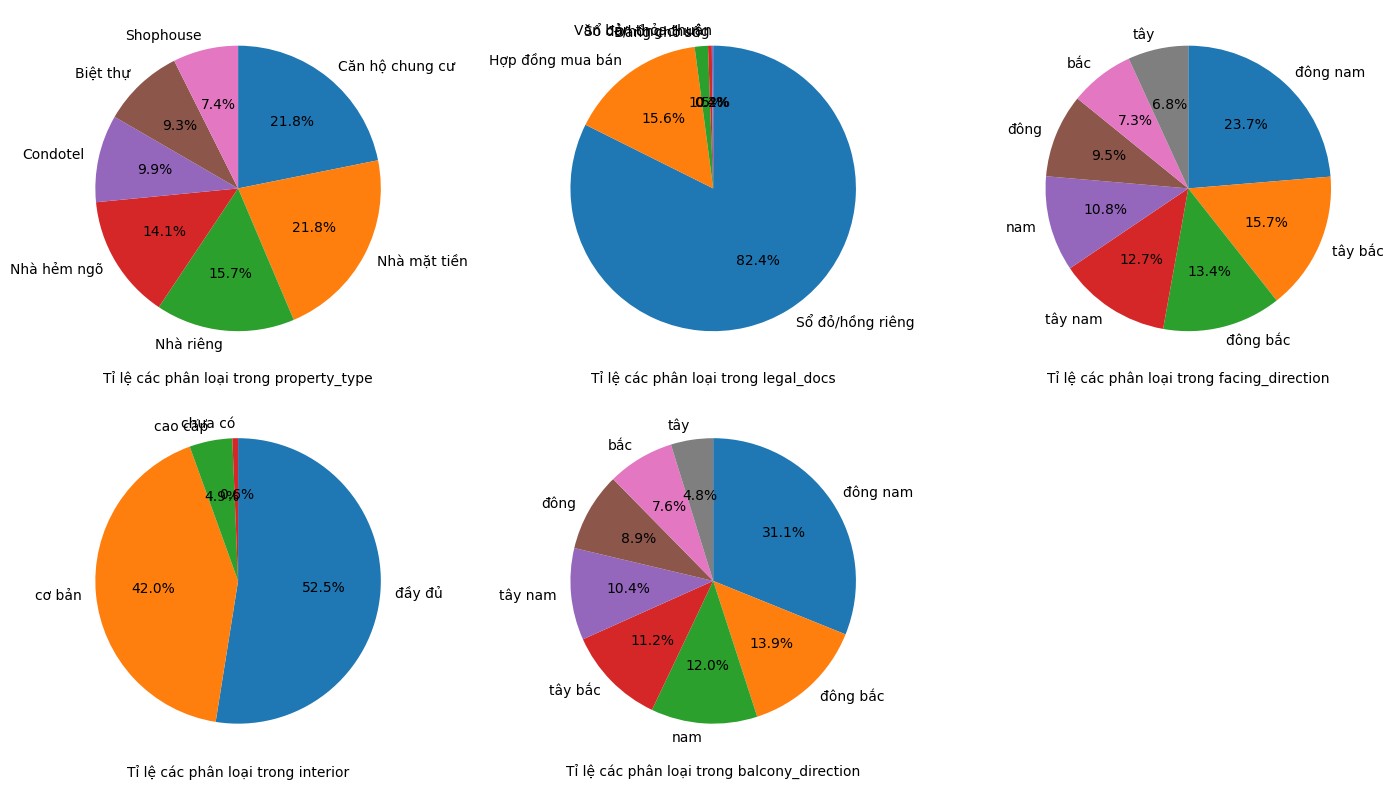

In [14]:
cat_cols = ['property_type', 'legal_docs', 'facing_direction', 'interior', 'balcony_direction']
fig, axs = plt.subplots(2,3, figsize = (14,8))
axs = axs.flatten()
for i in range(len(cat_cols)):
    axs[i].pie(
        df.groupby(cat_cols[i]).size().sort_values(ascending=False),
        labels=df.groupby(cat_cols[i]).size().sort_values(ascending=False).index,
        startangle=90,
        counterclock=False,
        autopct='%1.1f%%'
    )
    axs[i].set_xlabel(f'Tỉ lệ các phân loại trong {cat_cols[i]}')
axs[5].set_visible(False)
plt.tight_layout()
plt.show()

Hầu hết các bds đều có giấy tờ mua bán hợp lệ (Sổ đỏ/ hồng riêng)

Hướng Đông Nam nhiều nhất vừa trùng hợp là hướng tốt 
- Phong thủy: Tài lộc, phát triển, hòa thuận, sức khỏe.	
- Lợi thế khí hậu: Mát hè, ấm đông, tránh nắng gắt.

## **Bivariate**

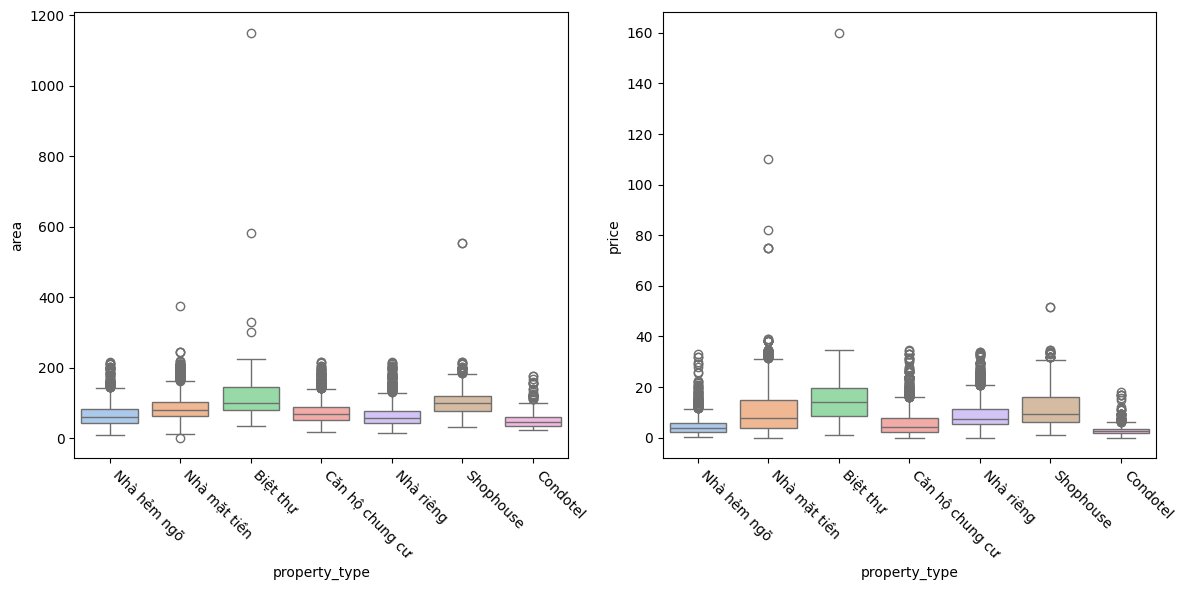

In [76]:
# # Q17: Average number of bedrooms by property_type (are villas bigger?)
# if set(['n_bedrooms','property_type']).issubset(df.columns):
#     gb = df.groupby('property_type')['n_bedrooms'].agg(['count','median','mean','std']).sort_values('mean', ascending=False)
#     group_results['bedrooms_by_property_type'] = gb
#     show_group("Q17: n_bedrooms by property_type", gb)
fig, axs = plt.subplots(1,2,figsize=(12,6))

sns.boxplot(df, x='property_type', y='area', hue='property_type', palette='pastel', ax=axs[0])

sns.boxplot(df, x='property_type', y='price', hue='property_type', palette='pastel', ax=axs[1])

for ax in axs:
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')

plt.tight_layout()
plt.show()

Biệt thự thường sẽ rộng hơn và mắc hơn phần lớn các loại bds ở khác

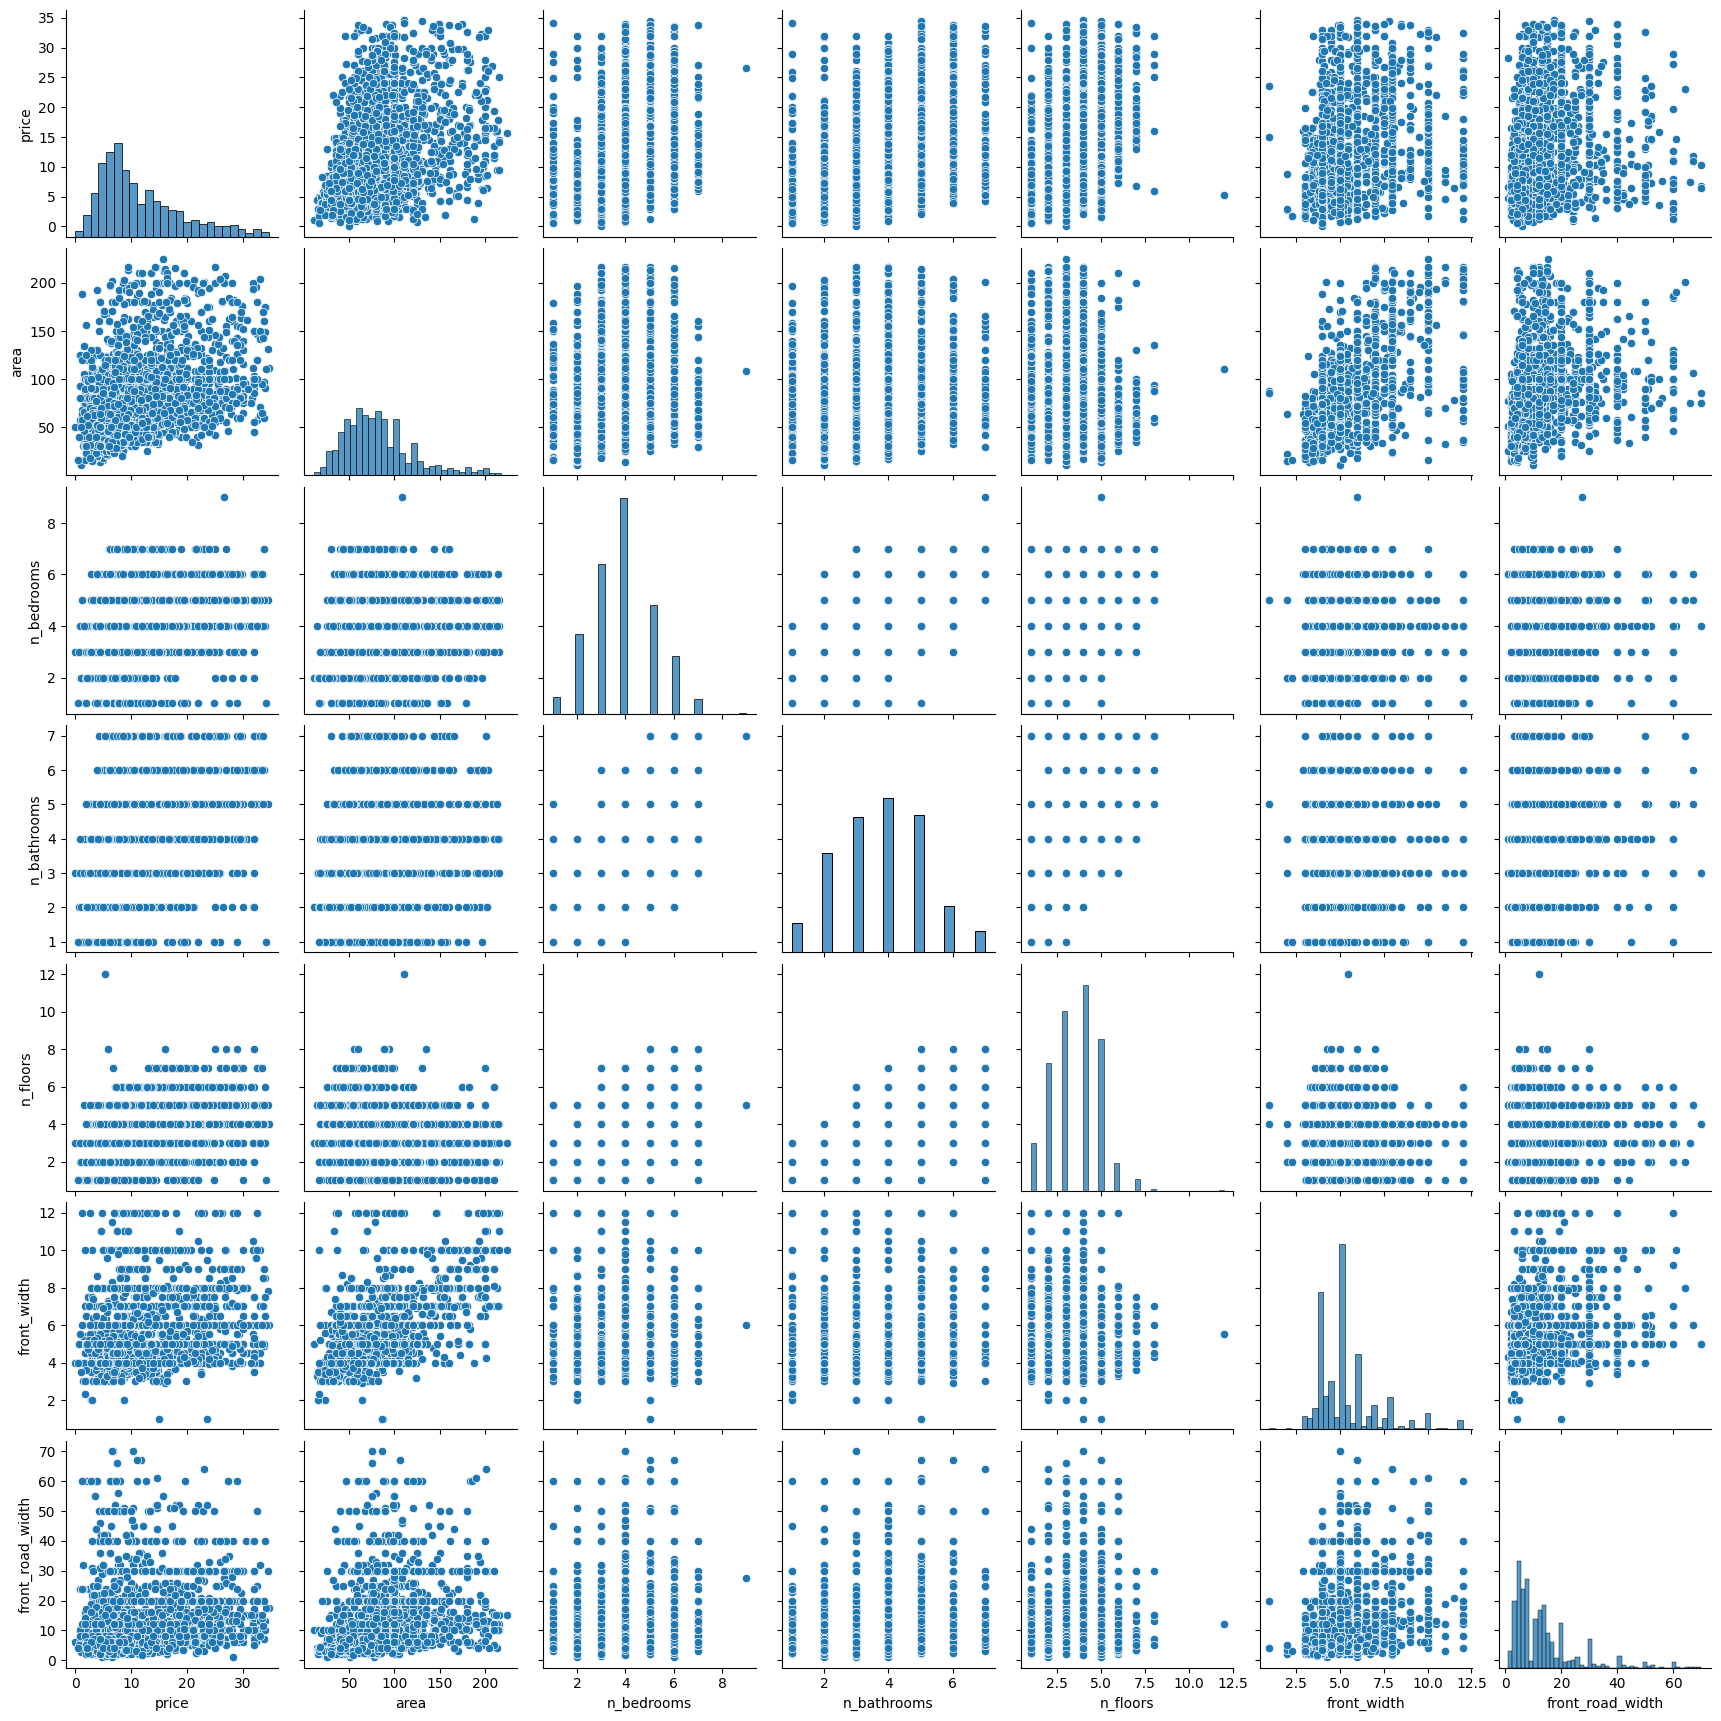

In [77]:
# for better visualization, restrict numeric ranges further
df_pair = df.loc[
    (df.area < 250) &
    (df.n_floors <= 14) &
    (df.front_road_width < 80) &
    (df.price < 45)
]
sns.pairplot(df_pair, )

In [78]:
def certainty_label(p):
    if p < 0.001:
        return "very certain (p < 0.001)"
    elif p < 0.05:
        return "moderately certain (p < 0.05)"
    elif p < 0.1:
        return "weak certainty (p < 0.1)"
    else:
        return "no certainty (p > 0.1)"

numeric_for_corr = ['price','area','front_width','front_road_width','n_bedrooms','n_bathrooms','n_floors']
pearson_results = []
for i, col1 in enumerate(numeric_for_corr):
    for col2 in numeric_for_corr[i+1:]:
        a = df[[col1,col2]].dropna()
        if len(a) >= 5:
            r, p = stats.pearsonr(a[col1], a[col2])
            pearson_results.append({'var1':col1, 'var2':col2, 'pearson_r':r, 'p_value':p, 'certainty': certainty_label(p), 'n':len(a)})
pearson_df = pd.DataFrame(pearson_results).sort_values('p_value')
pearson_df

,var1,var2,pearson_r,p_value,certainty,n
0,price,area,0.400634,0.000000e+00,very certain (p < 0.001),10096
3,price,n_bedrooms,0.518590,0.000000e+00,very certain (p < 0.001),8375
6,area,front_width,0.608633,0.000000e+00,very certain (p < 0.001),5990
4,price,n_bathrooms,0.530577,0.000000e+00,very certain (p < 0.001),7884
18,n_bedrooms,n_bathrooms,0.856325,0.000000e+00,very certain (p < 0.001),8327
8,area,n_bedrooms,0.287171,1.008185e-168,very certain (p < 0.001),8909
20,n_bathrooms,n_floors,0.327211,2.159780e-118,very certain (p < 0.001),4728
1,price,front_width,0.291906,2.970039e-113,very certain (p < 0.001),5746
19,n_bedrooms,n_floors,0.292633,2.865220e-98,very certain (p < 0.001),4947
9,area,n_bathrooms,0.218090,1.045770e-90,very certain (p < 0.001),8373


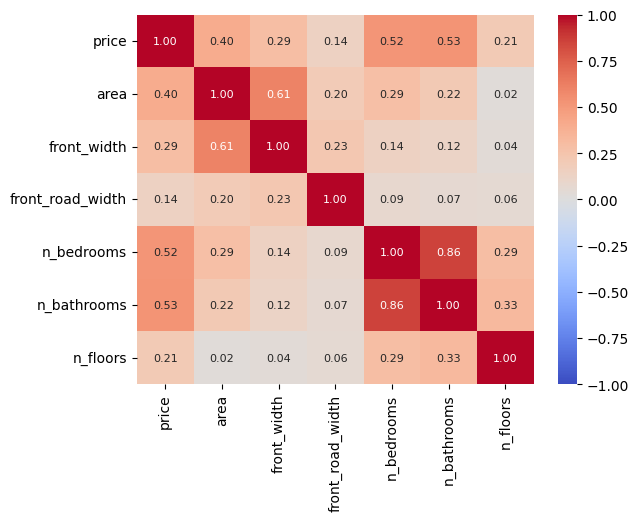

In [79]:
corr_mat = df[['price','area','front_width','front_road_width','n_bedrooms','n_bathrooms','n_floors']].corr()
sns.heatmap(corr_mat,annot=True,cmap='coolwarm',fmt=".2f", vmin=-1, vmax=1,
    annot_kws={"size": 8})
plt.show()

`n_bedrooms` and `n_bathrooms` correlation coefficient is almost 1, so why in the scatter plot they look so spread out?

<Axes: xlabel='n_bathrooms', ylabel='n_bedrooms'>

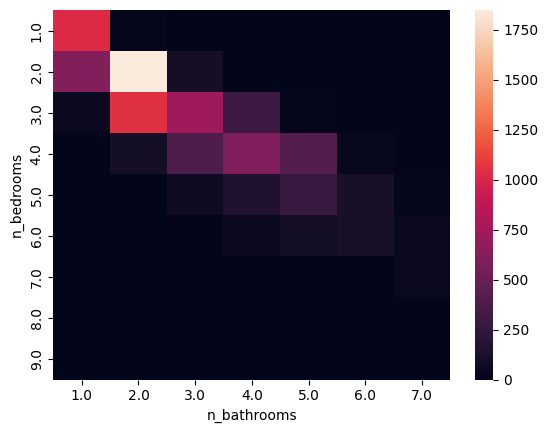

In [80]:
pivot = df.pivot_table(index='n_bedrooms', columns='n_bathrooms', values='property_type', aggfunc="count")
pivot.fillna(0, inplace=True)
sns.heatmap(pivot)

$\Rightarrow$ Most house has roughly equal number of bedrooms and bathrooms

## **Multivariate** 

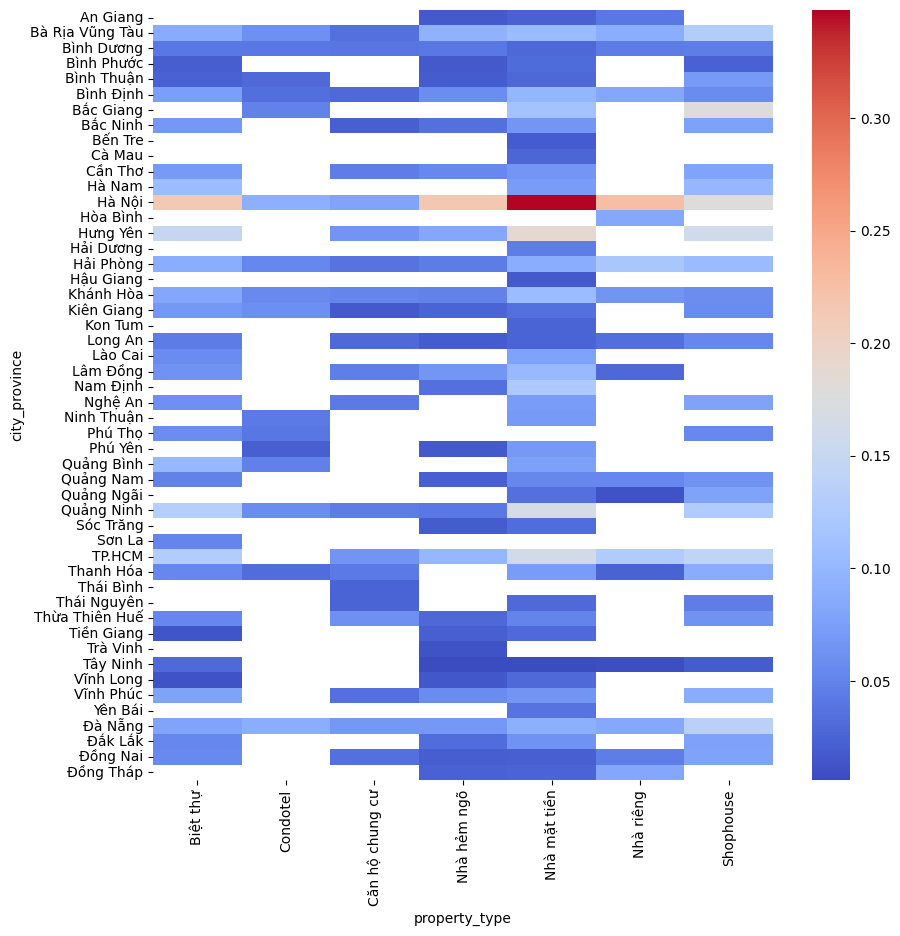

In [81]:
# Q16: Median price per m2 by property_type and city_province (pivot table)
df['price_per_m2'] = df['price'] / df['area'] 
pivot = df.pivot_table(index='property_type', columns='city_province', values='price_per_m2', aggfunc='median')

plt.figure(figsize=(10, 10))
sns.heatmap(pivot.T, cmap='coolwarm', cbar=True)
# plt.tight_layout()
plt.show()

In [82]:
# Q18: Median price by property_type and legal_docs
pivot = df.pivot_table(index='property_type', columns='legal_docs', values='price', aggfunc='median')
pivot

legal_docs,Hợp đồng mua bán,Sổ đỏ/hồng chung,Sổ đỏ/hồng riêng,Văn bản thỏa thuận,Đang chờ sổ
property_type,,,,,
Biệt thự,12.995,17.00,13.975,NaN,11.500
Condotel,2.700,NaN,2.600,NaN,1.700
Căn hộ chung cư,3.750,2.95,4.500,2.5000,5.400
Nhà hẻm ngõ,1.300,NaN,3.800,NaN,1.530
Nhà mặt tiền,2.130,NaN,7.600,1.9745,5.000
Nhà riêng,3.850,1.70,7.500,1.5990,3.285
Shophouse,7.870,NaN,9.900,10.5000,10.010


Properties with legitimate documents (sổ đỏ/hồng riêng) has the highest/second highest price across all property types 

## Checkpoint 2: Cleaned dataset

In [ ]:
# df.to_csv('../data/processed/cleaned.csv')